# 1000 Genomes Analysis

## Line plot of base-pair location (midpoint) vs per-tree distance, by population.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

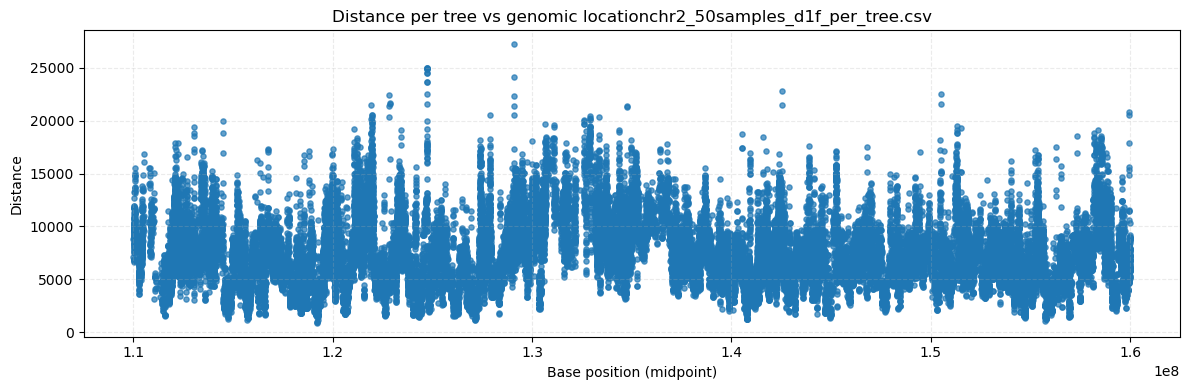

In [2]:
base = Path('.')
candidates = [ 
    base / 'chr2_50samples_dif_per_tree.csv',
    base / 'chr2_50samples_d1f_per_tree.csv',
    base / 'dif_per_tree.csv',
    base / 'd1f_per_tree.csv',
]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('No distance CSV found. Expected one of: ' + ', '.join(str(p.name) for p in candidates))

df = pd.read_csv(csv_path)

if 'mid' not in df.columns:
    raise KeyError("Column 'mid' not found in distance CSV.")

dist_col = None
for c in ['distance', 'd1f_distance', 'dif_distance']:
    if c in df.columns:
        dist_col = c
        break
if dist_col is None:
    raise KeyError("No distance column found. Tried: distance, d1f_distance, dif_distance")

plt.figure(figsize=(12, 4))
plt.scatter(df['mid'], df[dist_col], s=14, alpha=0.7)
plt.xlabel('Base position (midpoint)')
plt.ylabel('Distance')
plt.title(f'Distance per tree vs genomic location{csv_path.name}')
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

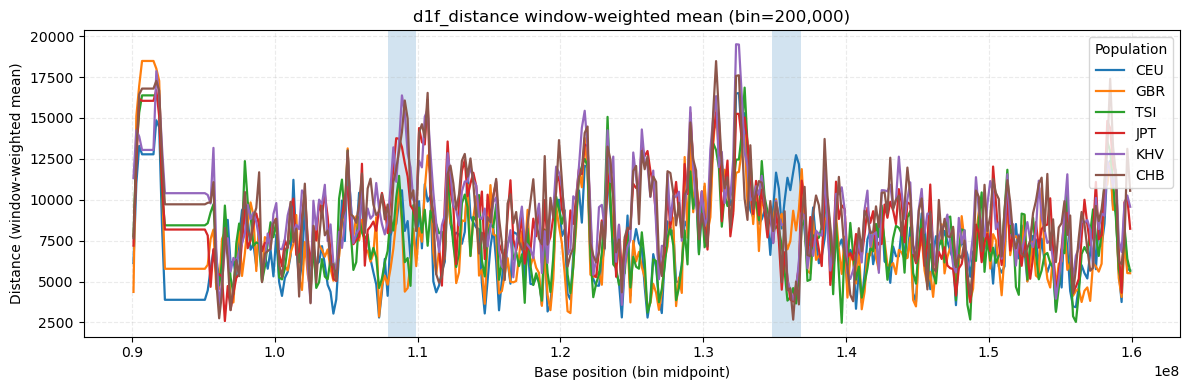

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load CSVs (per population)
# -----------------------
base = Path(".")
results_dir = base / "results"

# NOTE: 1000 Genomes population is CEU (not CER)
target_pops = ["CEU", "GBR", "TSI", "JPT", "KHV", "CHB"]

csv_paths = {pop: results_dir / f"chr2_50samples_{pop}_d1f_per_tree.csv" for pop in target_pops}

missing = [pop for pop, p in csv_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing distance CSV(s): "
        + ", ".join(f"{pop} ({csv_paths[pop].name})" for pop in missing)
    )

# Read CSVs
dfs = {pop: pd.read_csv(path) for pop, path in csv_paths.items()}

# Detect distance column (assume consistent across files)
dist_candidates = ["distance", "d1f_distance", "dif_distance"]
dist_col = next((c for c in dist_candidates if c in next(iter(dfs.values())).columns), None)
if dist_col is None:
    raise KeyError("No distance column found. Tried: " + ", ".join(dist_candidates))

# Validate + coerce types
required_cols = ["left", "right", dist_col]
for pop, df in dfs.items():
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"{pop}: missing columns {missing_cols} in {csv_paths[pop].name}")

    df = df.copy()
    for c in required_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=required_cols)
    df = df[df["right"] > df["left"]]
    df = df.sort_values("left")

    dfs[pop] = df

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

x0 = min(df["left"].min() for df in dfs.values())
x1 = max(df["right"].max() for df in dfs.values())

# snap to bin edges
x0 = (int(x0) // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)

    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines)
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# LCT LP canonical site (hg38 rs4988235) ~135,851,076
pos = 135_851_076
half = 1_000_000  # +/- 1 Mb
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

for pop, df in dfs.items():
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,})")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()


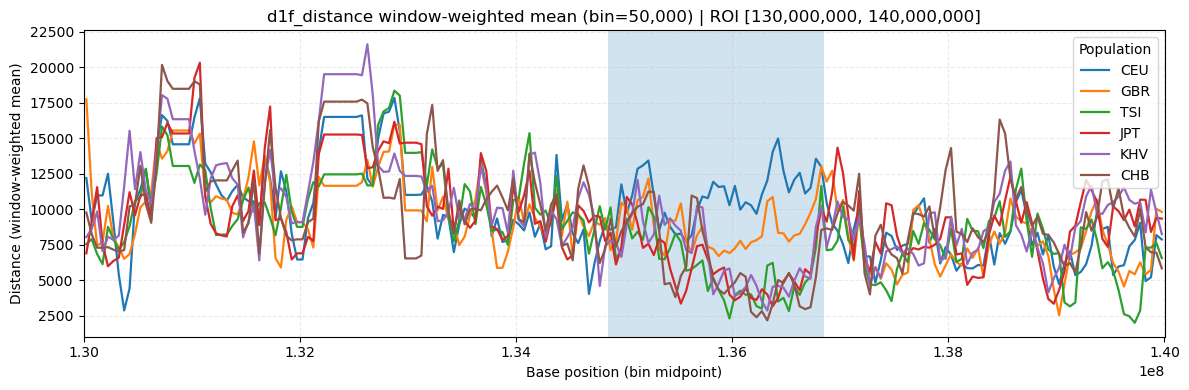

In [ ]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.3e8)
ROI_R = int(1.4e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 50_00

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the LCT highlight if it falls in ROI (it does)
pos = 135_851_076
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()

In [5]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.0e8)
ROI_R = int(1.1e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the EDAR highlight if it falls in ROI (it does)
pos = 108_897_145
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'items'

## CEU vs JPT: Location vs mean D1F (post-burn-in, bin=100,000)

This section loads post-burn-in per-sample D1F CSVs from the new ARGweaver output layout, bins by 100,000 bp, and averages the binned curve over MCMC samples for each population (CEU, JPT).


CEU: 21 MCMC samples used
JPT: 21 MCMC samples used


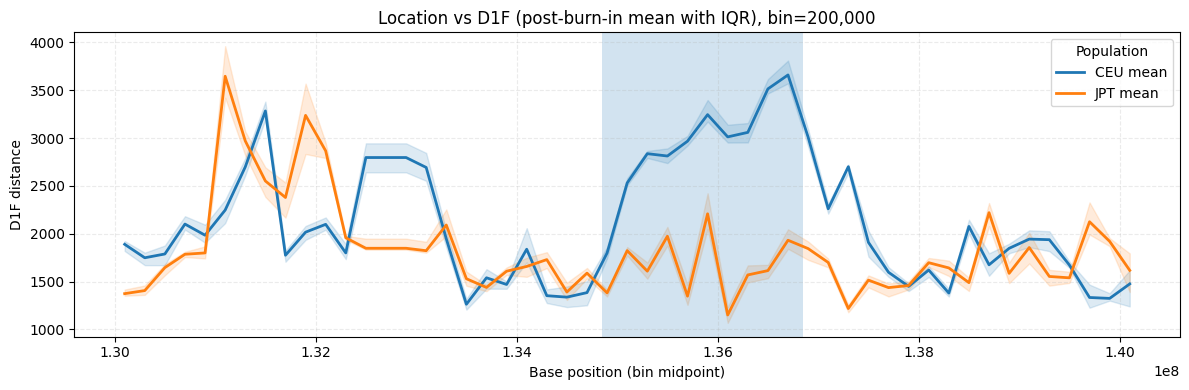

In [6]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path('.')
results_root = base / 'raw_data' / 'data' / 'results'

target_pops = ['CEU', 'JPT']
bin_size = 200_000

def load_pop_samples(pop: str):
    pattern = f'*_{pop}20/d1f_postburnin/*_d1f_per_tree_postburnin.csv'
    csv_paths = sorted(results_root.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f'No post-burn-in CSVs found for {pop} under {results_root}')

    sample_dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)

        dist_col = next((c for c in ['d1f_distance', 'distance', 'dif_distance'] if c in df.columns), None)
        if dist_col is None:
            raise KeyError(f'{p}: missing distance column')
        if not {'left', 'right'}.issubset(df.columns):
            raise KeyError(f'{p}: missing left/right columns')

        sample_match = re.search(r'sample(\d+)', p.name.lower())
        sample_id = int(sample_match.group(1)) if sample_match else None

        d = df[['left', 'right', dist_col]].copy()
        d.columns = ['left', 'right', 'd1f']
        d['sample'] = sample_id

        for c in ['left', 'right', 'd1f']:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        d = d.dropna(subset=['left', 'right', 'd1f'])
        d = d[d['right'] > d['left']]
        d = d.sort_values('left')

        if len(d):
            sample_dfs.append(d)

    if not sample_dfs:
        raise ValueError(f'All sample files for {pop} were empty after cleaning.')

    return sample_dfs

def binned_weighted_mean(df: pd.DataFrame, bin_left, bin_right):
    seg_left = df['left'].to_numpy(dtype=float)
    seg_right = df['right'].to_numpy(dtype=float)
    seg_val = df['d1f'].to_numpy(dtype=float)

    out = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            out[i] = np.sum(w * seg_val[m]) / np.sum(w)
    return out

# Load sample-level D1F data
pop_samples = {pop: load_pop_samples(pop) for pop in target_pops}

# Shared bin edges across both populations
x0 = min(df['left'].min() for dfs in pop_samples.values() for df in dfs)
x1 = max(df['right'].max() for dfs in pop_samples.values() for df in dfs)
x0 = (int(x0) // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

# Average (mean) curve over MCMC samples + quantile bands per population
pop_stats = {}
for pop, dfs in pop_samples.items():
    per_sample_curves = np.vstack([binned_weighted_mean(d, bin_left, bin_right) for d in dfs])

    pop_stats[pop] = {
        'mean': np.nanmean(per_sample_curves, axis=0),
        'median': np.nanmedian(per_sample_curves, axis=0),
        'q1': np.nanquantile(per_sample_curves, 0.25, axis=0),
        'q3': np.nanquantile(per_sample_curves, 0.75, axis=0),
    }
    print(f'{pop}: {len(dfs)} MCMC samples used')

# Plot 2 lines (means) + quantile bands (Q1-Q3), styled like neutral-overlay section
fig, ax = plt.subplots(figsize=(12, 4))
colors = {'CEU': 'tab:blue', 'JPT': 'tab:orange'}

for pop in target_pops:
    stats = pop_stats[pop]
    color = colors.get(pop, None)

    qmask = np.isfinite(stats['q1']) & np.isfinite(stats['q3'])
    ax.fill_between(bin_mid[qmask], stats['q1'][qmask], stats['q3'][qmask], color=color, alpha=0.15)

    mmask = np.isfinite(stats['mean'])
    ax.plot(bin_mid[mmask], stats['mean'][mmask], color=color, linewidth=2.0, label=f'{pop} mean')

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance')
ax.set_title(f'Location vs D1F (post-burn-in mean with IQR), bin={bin_size:,}')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Population')
fig.tight_layout()
plt.show()


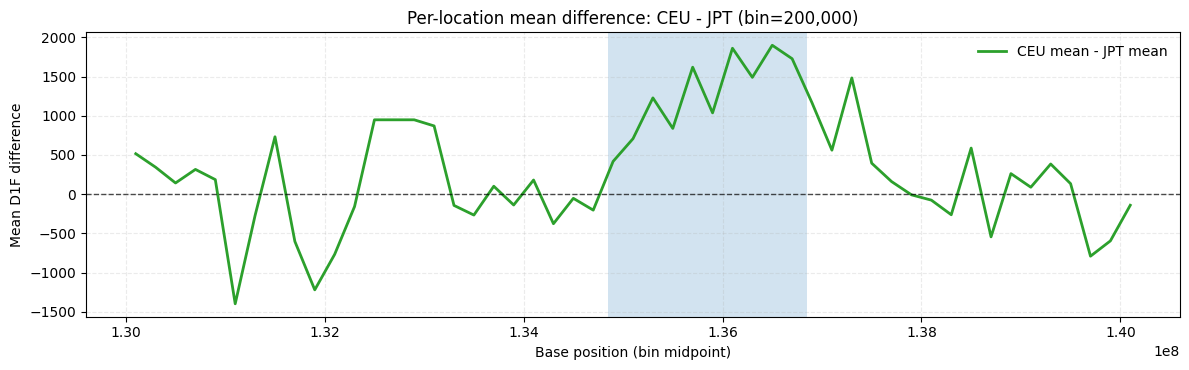

In [7]:
# CEU-JPT mean D1F difference per location (same bins as above)
diff_mean = pop_stats['CEU']['mean'] - pop_stats['JPT']['mean']
mask = np.isfinite(diff_mean)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(bin_mid[mask], diff_mean[mask], color='tab:green', linewidth=2.0, label='CEU mean - JPT mean')
ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('Mean D1F difference')
ax.set_title(f'Per-location mean difference: CEU - JPT (bin={bin_size:,})')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
